In [1]:
# %% [markdown]
# # Task 2: Technical Indicators - All Stocks
# **Author:** Meron Gebru | **Date:** May 2026

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
def sma(series, window):
    return series.rolling(window=window).mean()

def ema(series, window):
    return series.ewm(span=window, adjust=False).mean()

def rsi(series, window=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/window, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1/window, min_periods=window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def macd(series, fast=12, slow=26, signal=9):
    ema_fast = ema(series, fast)
    ema_slow = ema(series, slow)
    macd_line = ema_fast - ema_slow
    signal_line = ema(macd_line, signal)
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

print("✅ Indicator functions defined")

✅ Indicator functions defined


In [4]:
# %% [markdown]
# ## Load All 5 Stock Datasets

# %%
STOCKS = ['AAPL', 'GOOG', 'AMZN', 'NVDA', 'META']
DATA_DIR = Path('../data/raw')
REPORTS_DIR = Path('../reports')
REPORTS_DIR.mkdir(exist_ok=True)

stock_dfs = {}
for ticker in STOCKS:
    path = DATA_DIR / f"{ticker}.csv"
    if not path.exists():
        print(f"⚠️ {path} not found")
        continue
    
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    df = df.dropna(subset=['Close'])
    stock_dfs[ticker] = df
    print(f"✅ Loaded {ticker}: {len(df)} rows ({df.index.min().date()} to {df.index.max().date()})")

✅ Loaded AAPL: 3774 rows (2009-01-02 to 2023-12-29)
✅ Loaded GOOG: 3774 rows (2009-01-02 to 2023-12-29)
✅ Loaded AMZN: 3774 rows (2009-01-02 to 2023-12-29)
✅ Loaded NVDA: 3774 rows (2009-01-02 to 2023-12-29)
✅ Loaded META: 2923 rows (2012-05-18 to 2023-12-29)


In [5]:
# %% [markdown]
# ## Compute Indicators for All Stocks

# %%
for ticker, df in stock_dfs.items():
    price = df['Close']
    df['SMA_20'] = sma(price, 20)
    df['SMA_50'] = sma(price, 50)
    df['RSI_14'] = rsi(price, 14)
    macd_l, sig_l, hist = macd(price)
    df['MACD'] = macd_l
    df['MACD_Signal'] = sig_l
    df['MACD_Hist'] = hist
    df['Daily_Return'] = price.pct_change() * 100
    stock_dfs[ticker] = df.dropna()

print(f"\n✅ Indicators computed for {len(stock_dfs)} stocks")


✅ Indicators computed for 5 stocks


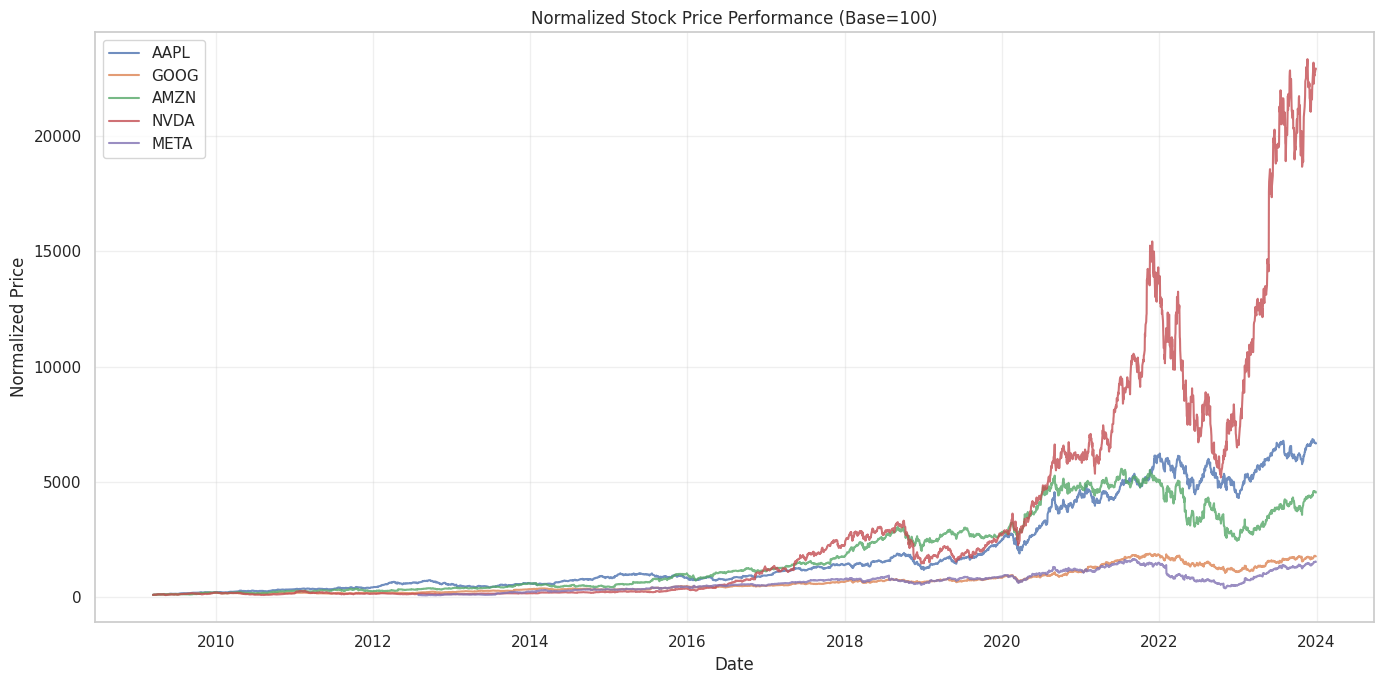

In [6]:
# %% [markdown]
# ## Visualize: Price Comparison (Normalized)

# %%
plt.figure(figsize=(14, 7))
for ticker, df in stock_dfs.items():
    # Normalize to 100 at start
    norm_price = 100 * df['Close'] / df['Close'].iloc[0]
    plt.plot(df.index, norm_price, label=ticker, linewidth=1.5, alpha=0.8)

plt.title('Normalized Stock Price Performance (Base=100)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'all_stocks_normalized.png', dpi=300)
plt.show()


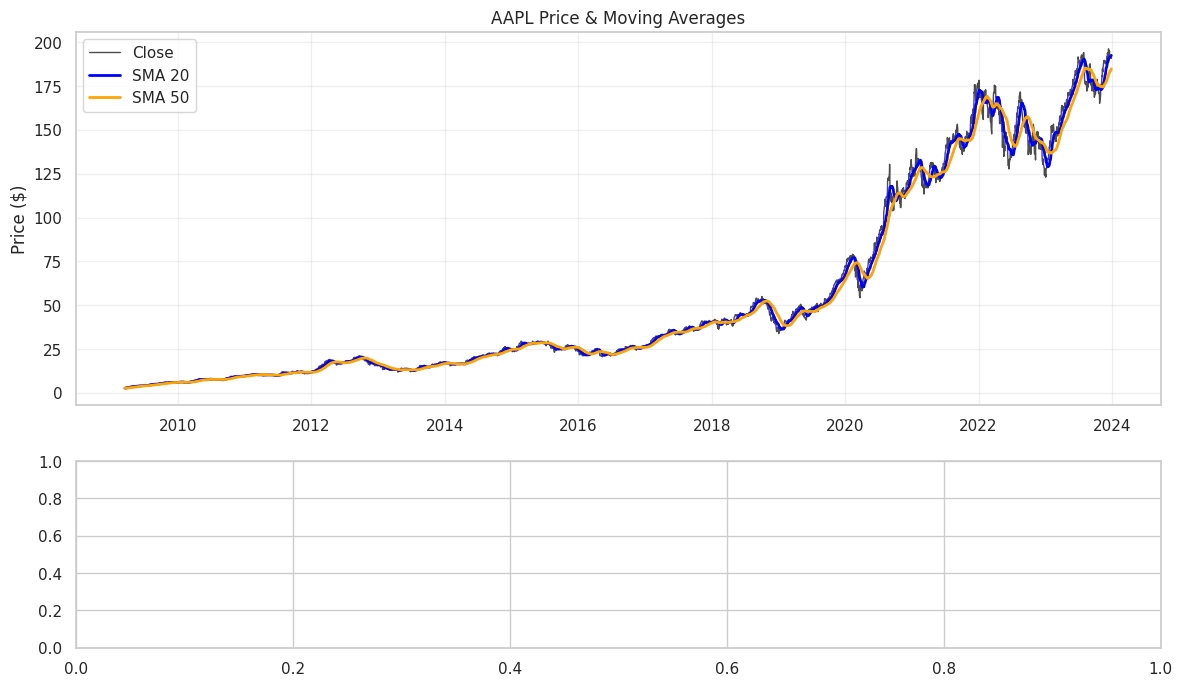

In [7]:
# %% [markdown]
# ## Visualize: Individual Stock Analysis (AAPL Example)

# %%
ticker = "AAPL"
df = stock_dfs[ticker]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

# Price + SMA
ax1.plot(df.index, df['Close'], label='Close', color='black', linewidth=1, alpha=0.7)
ax1.plot(df.index, df['SMA_20'], label='SMA 20', linewidth=2, color='blue')
ax1.plot(df.index, df['SMA_50'], label='SMA 50', linewidth=2, color='orange')
ax1.set_title(f'{ticker} Price & Moving Averages')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

In [9]:
# RSI
ax2.plot(df.index, df['RSI_14'], color='purple', linewidth=1)
ax2.axhline(70, color='red', linestyle='--', alpha=0.6, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.6, label='Oversold (30)')
ax2.set_title(f'{ticker} RSI')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / f'{ticker}_indicators.png', dpi=300)
plt.show()


<Figure size 1200x600 with 0 Axes>

In [10]:
# %% [markdown]
# ## Save Processed Data

# %%
for ticker, df in stock_dfs.items():
    out_path = REPORTS_DIR / f"{ticker}_indicators.csv"
    df.to_csv(out_path)
    print(f"💾 Saved {out_path}")

print("\n✅ Task 2 complete - all 5 stocks processed")

💾 Saved ../reports/AAPL_indicators.csv
💾 Saved ../reports/GOOG_indicators.csv
💾 Saved ../reports/AMZN_indicators.csv
💾 Saved ../reports/NVDA_indicators.csv
💾 Saved ../reports/META_indicators.csv

✅ Task 2 complete - all 5 stocks processed
